## Crop Classification Using Multi-class Logistic Regression

**1. Objective**

The goal of this project is to develop a classification model capable of predicting the most suitable crop based on soil characteristics:

- Nitrogen (N)
- Phosphorus (P)
- Potassium (K)
- pH level

The dataset contains 2200 observations across 22 crop classes, making this a multi-class classification problem.

**2. Importing Packages**

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge, Lasso

**3. Reading and Exploring the Data**

In [139]:
crops_df = pd.read_csv("soil_measures.csv")
crops_df.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


**3.1 Feature Summary**

| Feature | Mean  | Std Dev | Min  | Max  |
| ------- | ----- | ------- | ---- | ---- |
| N       | 50.55 | 36.92   | 0    | 140  |
| P       | 53.36 | 32.99   | 5    | 145  |
| K       | 48.15 | 50.65   | 5    | 205  |
| pH      | 6.47  | 0.77    | 3.50 | 9.93 |

- pH has a relatively tight distribution
- K (potassium) shows the largest variability, indicating diverse soil potassium level

In [140]:
# Features distribution
crops_df.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [141]:
# Count the number of records for each crop
# crops_df["crop"].value_counts().max() - crops_df["crop"].value_counts().min()

**3.2 Information about the Dataset** 

In [142]:
crops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


**3.3 Soil Nutrtent Distribution Across Crops**

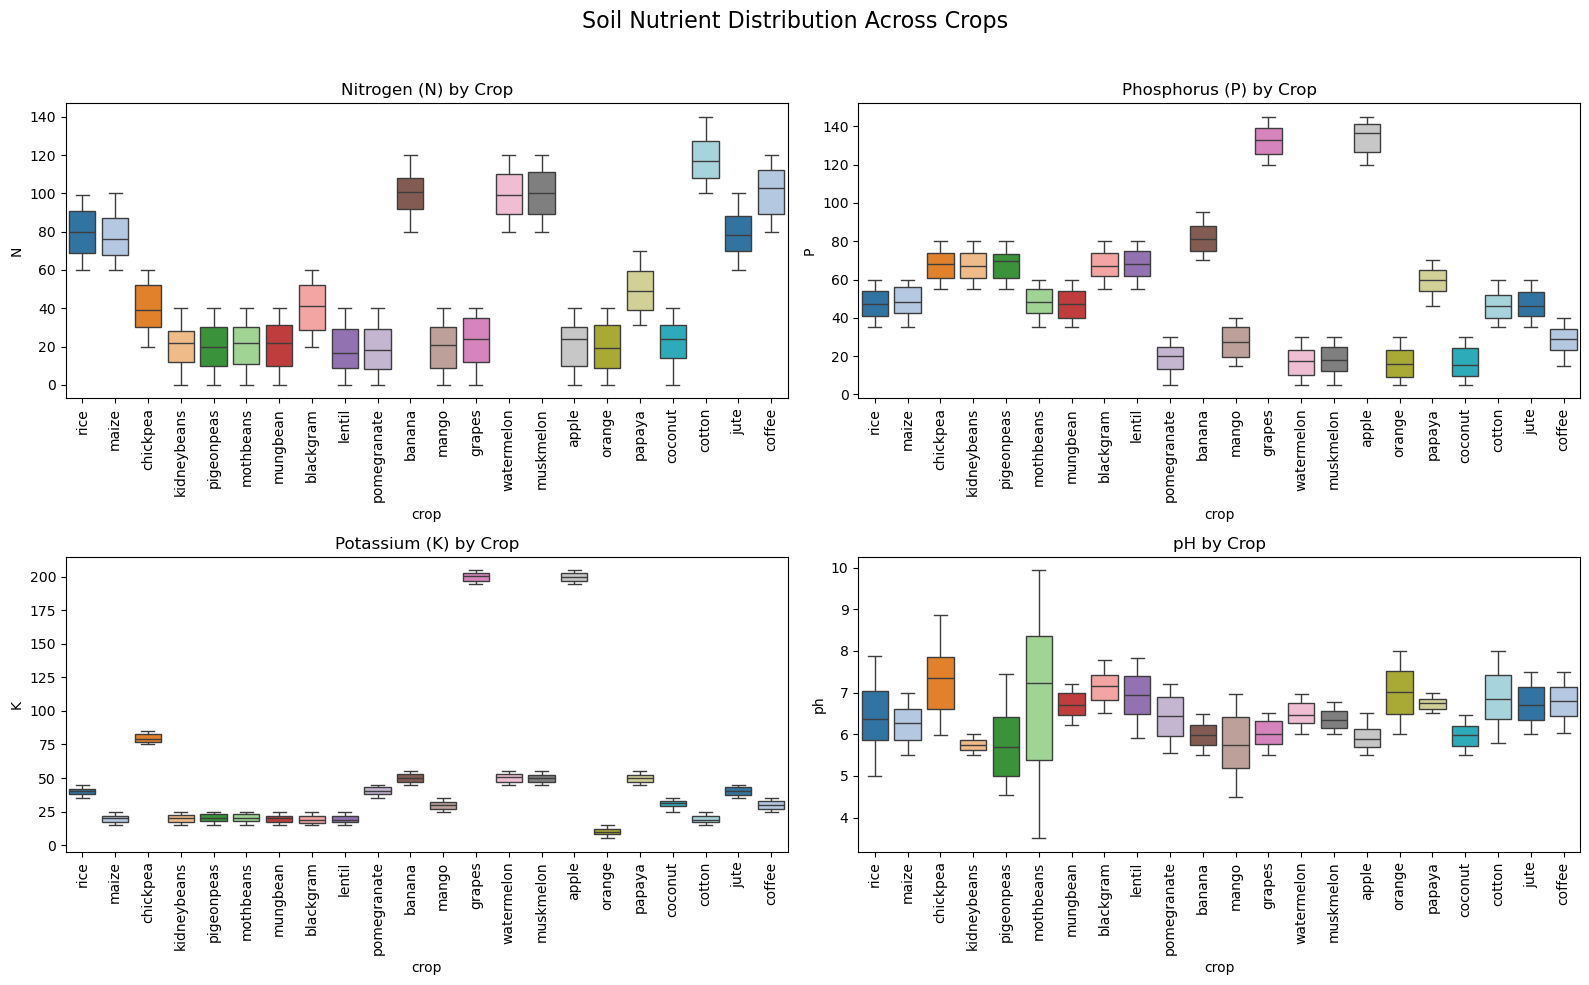

In [185]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=crops_df, x="crop", y="N", hue="crop", palette="tab20", ax=axes[0, 0], legend=False)
sns.boxplot(data=crops_df, x="crop", y="P", hue="crop", palette="tab20", ax=axes[0, 1], legend=False)
sns.boxplot(data=crops_df, x="crop", y="K", hue="crop", palette="tab20", ax=axes[1, 0], legend=False)
sns.boxplot(data=crops_df, x="crop", y="ph", hue="crop", palette="tab20", ax=axes[1, 1], legend=False)

# Titles
axes[0, 0].set_title("Nitrogen (N) by Crop")
axes[0, 1].set_title("Phosphorus (P) by Crop")
axes[1, 0].set_title("Potassium (K) by Crop")
axes[1, 1].set_title("pH by Crop")

# Rotate labels
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=90)

plt.suptitle("Soil Nutrient Distribution Across Crops", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

**3.4 Soil Nutrient Distribution by Crop Type**

In [ ]:
crop_groups = {
    "rice": "Cereal", 
    "maize": "Cereal",
    "chickpea": "Pulse", 
    "kidneybeans": "Pulse", 
    "pigeonpeas": "Pulse",
    "mothbeans": "Pulse", 
    "mungbean": "Pulse", 
    "blackgram": "Pulse", 
    "lentil": "Pulse",
    "pomegranate": "Fruit", 
    "banana": "Fruit", 
    "mango": "Fruit",
    "grapes": "Fruit", 
    "watermelon": "Fruit", 
    "muskmelon": "Fruit", 
    "apple": "Fruit", 
    "orange": "Fruit", 
    "papaya": "Fruit", 
    "coconut": "Fruit",
    "cotton": "Cash Crop", 
    "jute": "Cash Crop", 
    "coffee": "Cash Crop"
}

crops_df["crop_type"] = crops_df["crop"].map(crop_groups)
crops_df.tail()

,N,P,K,ph,crop,crop_type
2195,107,34,32,6.780064,coffee,Cash Crop
2196,99,15,27,6.086922,coffee,Cash Crop
2197,118,33,30,6.362608,coffee,Cash Crop
2198,117,32,34,6.758793,coffee,Cash Crop
2199,104,18,30,6.779833,coffee,Cash Crop


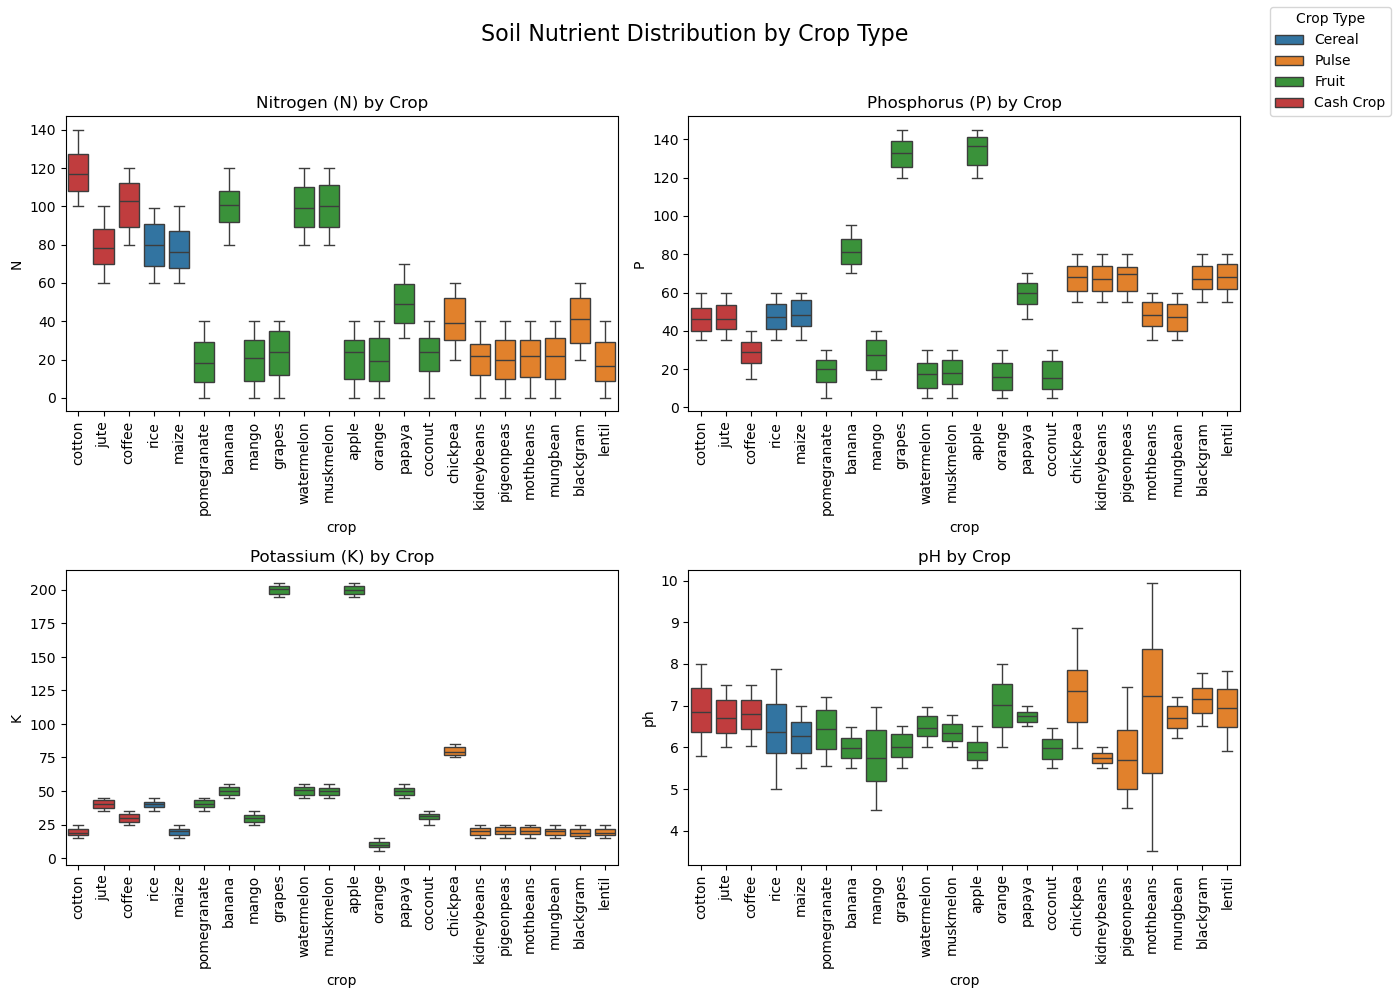

In [189]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

order = sorted(crops_df["crop"], key=lambda x: crop_groups[x])

sns.boxplot(data=crops_df, x="crop", y="N", hue="crop_type", order=order, ax=axes[0, 0])
sns.boxplot(data=crops_df, x="crop", y="P", hue="crop_type", order=order, ax=axes[0, 1])
sns.boxplot(data=crops_df, x="crop", y="K", hue="crop_type", order=order, ax=axes[1, 0])
sns.boxplot(data=crops_df, x="crop", y="ph", hue="crop_type", order=order, ax=axes[1, 1])

# Titles
axes[0, 0].set_title("Nitrogen (N) by Crop")
axes[0, 1].set_title("Phosphorus (P) by Crop")
axes[1, 0].set_title("Potassium (K) by Crop")
axes[1, 1].set_title("pH by Crop")

# Rotate labels
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=90)

# Move legend outside (cleaner)
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, title="Crop Type", loc="upper right")

# Remove duplicate legends
for ax in axes.flat:
    ax.get_legend().remove()

plt.suptitle("Soil Nutrient Distribution by Crop Type", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.96])

plt.show()

- 🌾 Cereals → often high nitrogen demand
- 🌱 Pulses → lower nitrogen and potassium level
- 🍎 Fruits → balanced nutrients
- 💰 Cash crops → specific nutrient profiles (high nitrogen demand, low phosphorus and potassium demands)

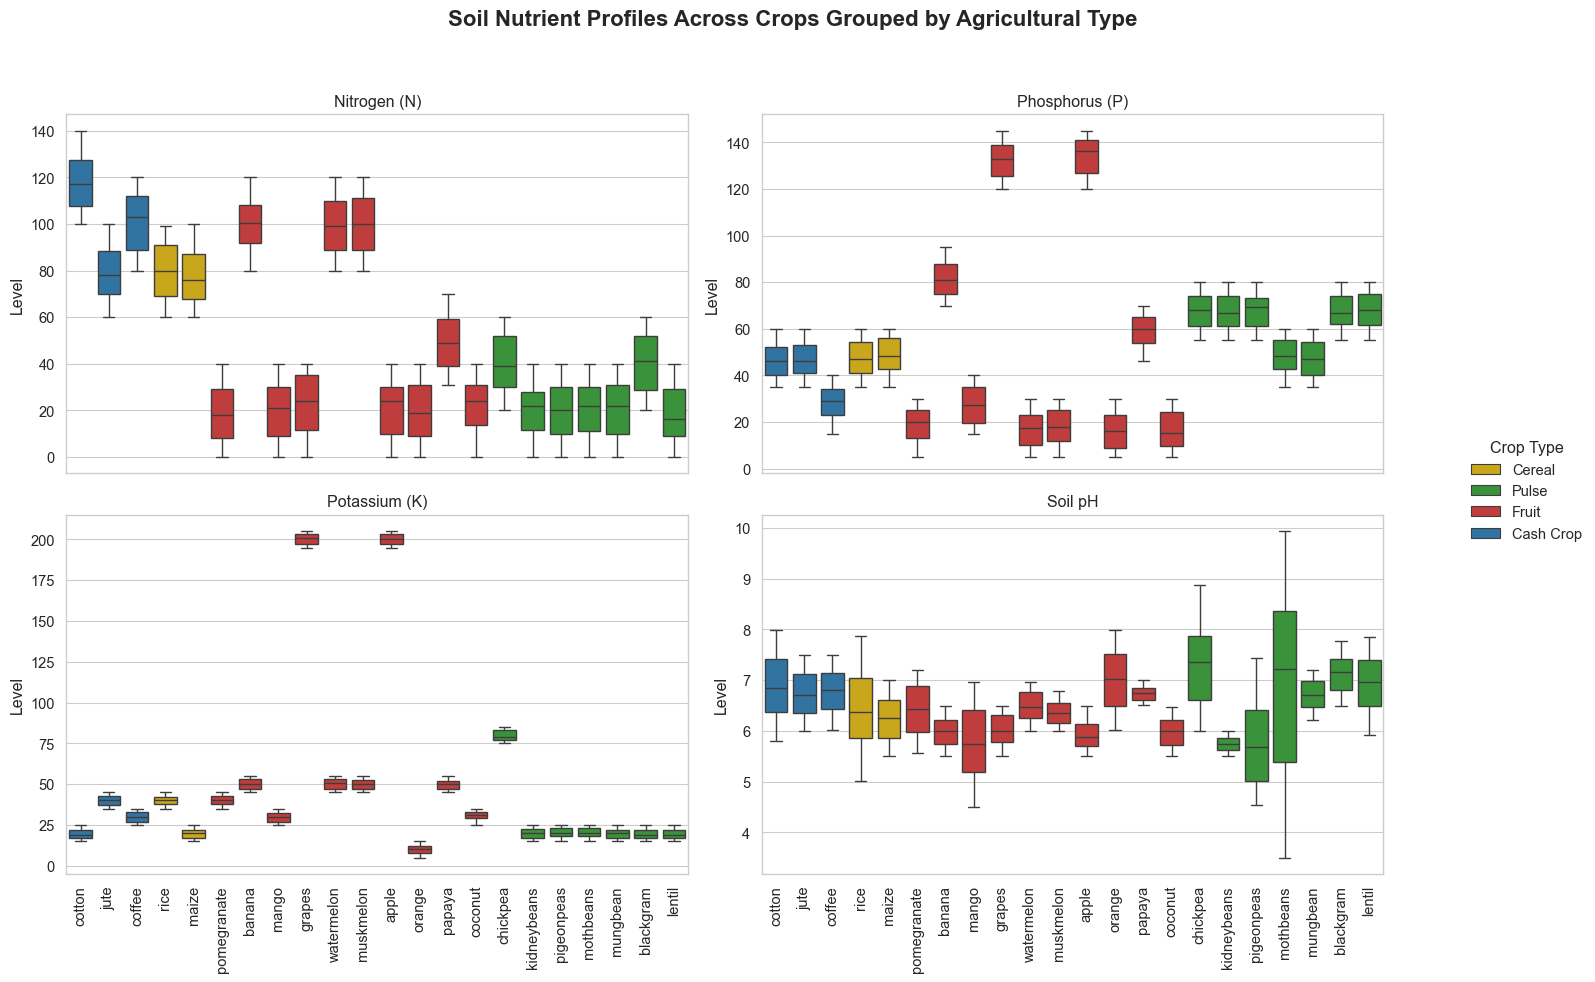

In [193]:
# Style (important for publication look)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Define consistent palette for crop types
palette = {
    "Cereal": "#E6B800",     # gold
    "Pulse": "#2CA02C",      # green
    "Fruit": "#D62728",      # red
    "Cash Crop": "#1F77B4"   # blue
}

# Order crops by type (clean grouping)
order = sorted(crops_df["crop"], key=lambda x: crops_df[crops_df["crop"] == x]["crop_type"].iloc[0])

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Plot each variable
sns.boxplot(data=crops_df, x="crop", y="N", hue="crop_type", palette=palette, order=order, ax=axes[0, 0])
sns.boxplot(data=crops_df, x="crop", y="P", hue="crop_type", palette=palette, order=order, ax=axes[0, 1])
sns.boxplot(data=crops_df, x="crop", y="K", hue="crop_type", palette=palette, order=order, ax=axes[1, 0])
sns.boxplot(data=crops_df, x="crop", y="ph", hue="crop_type", palette=palette, order=order, ax=axes[1, 1])

# Titles (concise & professional)
axes[0, 0].set_title("Nitrogen (N)")
axes[0, 1].set_title("Phosphorus (P)")
axes[1, 0].set_title("Potassium (K)")
axes[1, 1].set_title("Soil pH")

# Axis labels
for ax in axes.flat:
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel("Level")

# Remove duplicate legends
for ax in axes.flat:
    ax.get_legend().remove()

# Create single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Crop Type", loc="center right", frameon=False)

# Main title
plt.suptitle("Soil Nutrient Profiles Across Crops Grouped by Agricultural Type",
             fontsize=16, fontweight="bold")

# Layout adjustments
plt.tight_layout(rect=[0, 0, 0.88, 0.95])

# Save high-quality figure
plt.savefig("publication_figure.png", dpi=300, bbox_inches="tight")

plt.show()

**4. Crop Classification using Logistic Regression**

**4.1 Building and Evaluating a multiclass Logistic Regression Model**

In [143]:
X = crops_df.drop("crop", axis=1)
y = crops_df["crop"]

# Train-test split (stratify is IMPORTANT for 22 classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# Create model (multiclass)
model = LogisticRegression(
    multi_class="multinomial",   # key for multiclass
    solver="lbfgs",
    max_iter=1000
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

import warnings
warnings.filterwarnings("ignore")

# Evaluation
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.634090909090909


**4.2 Feature Importance**

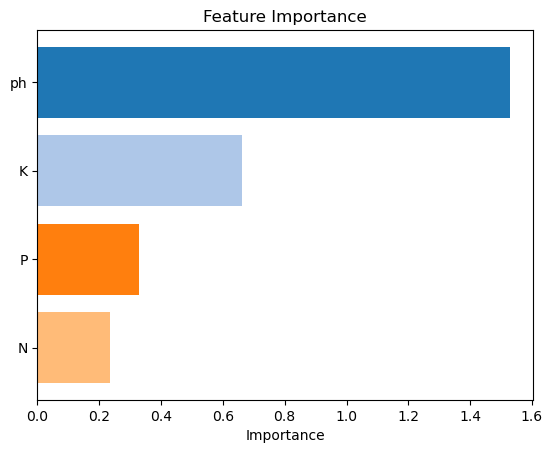

In [144]:
# Get coefficients
coefficients = model.coef_

# Compute importance (mean of absolute values across classes)
importance = np.mean(np.abs(coefficients), axis=0)

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": crops_df.drop("crop", axis=1).columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Generate colors
colors = plt.cm.tab20(range(len(feature_importance)))

# Plot
plt.figure()
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [145]:
feature_importance

,Feature,Importance
3,ph,1.527961
2,K,0.661290
1,P,0.328571
0,N,0.236078


The feature importance analysis highlights soil pH as the most influential factor in predicting crop type, which aligns with well-established agricultural knowledge. Soil pH affects nutrient availability, microbial activity, and overall soil chemistry, making it a primary determinant of plant growth (Brady & Weil, 2017). Most crops perform optimally within a slightly acidic to neutral pH range (approximately 6–7), where essential nutrients like nitrogen, phosphorus, and potassium are readily accessible (Havlin et al., 2014). Outside this range, nutrient uptake can be limited or certain elements can become toxic, reducing plant development regardless of nutrient concentration (Marschner, 2012). Therefore, even if other nutrients are present at adequate levels, inappropriate pH can severely constrain growth. This explains why pH dominates the model’s predictions, while other soil nutrients such as potassium, phosphorus, and nitrogen contribute more modestly. These results demonstrate that the model effectively captures key agronomic principles, reinforcing the practical relevance of soil pH in determining crop suitability.

**4.3 Scaling the Features**

In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

import warnings
warnings.filterwarnings("ignore")

# Evaluation
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6590909090909091


Scaling improved the model’s performance slightly, confirming that the features had different scales that influenced the algorithm.

In [147]:
crops = crops_df["crop"].unique()
features = list(crops_df.drop("crop", axis=1).columns)

df_coef = pd.DataFrame(coefficients, columns=features)
df_coef["Crop"] = crops

**Visualizing Feature Importance Across Crops**

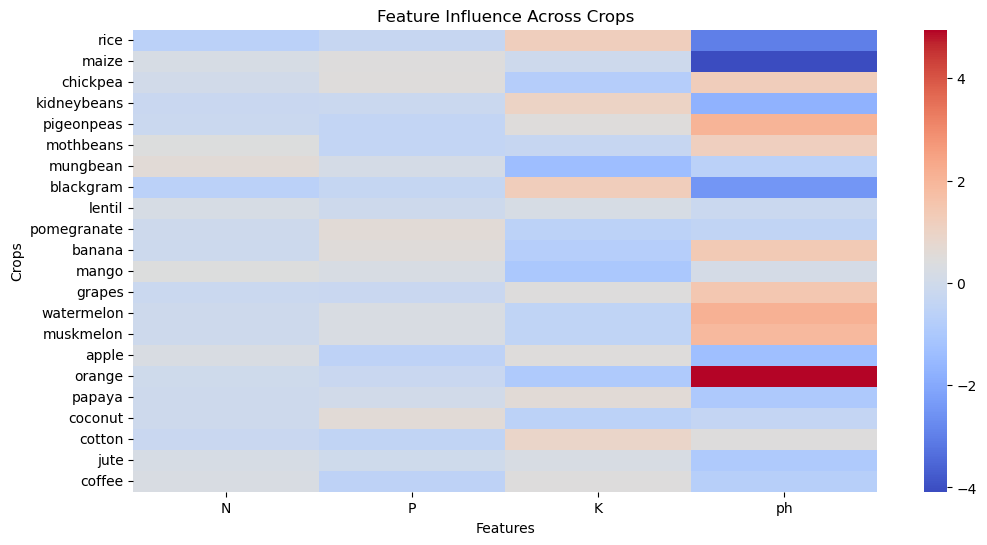

In [148]:
plt.figure(figsize=(12,6))
sns.heatmap(df_coef[features], cmap="coolwarm", yticklabels=crops)
plt.title("Feature Influence Across Crops")
plt.xlabel("Features")
plt.ylabel("Crops")
plt.show()

**Top 10 most ph-sensitive crops**

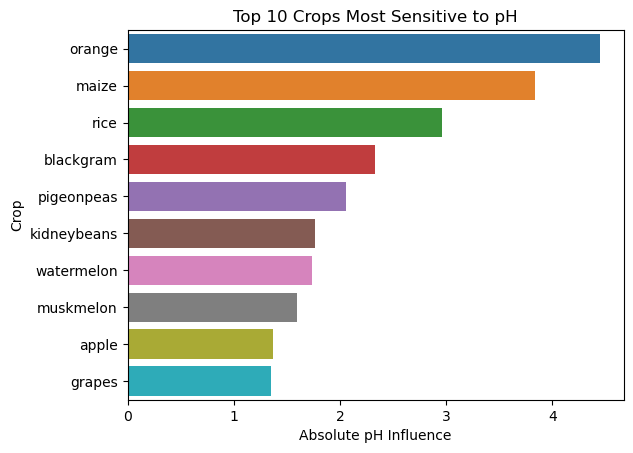

In [149]:
top10 = df_sorted.head(10)

plt.figure()
sns.barplot(top10, x="abs_ph", y="Crop", hue="Crop")
plt.xlabel("Absolute pH Influence")
plt.title("Top 10 Crops Most Sensitive to pH")
plt.show()

**4.4 Confusion matrix**

In [150]:
classes = df_coef["Crop"]
cm = metrics.confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

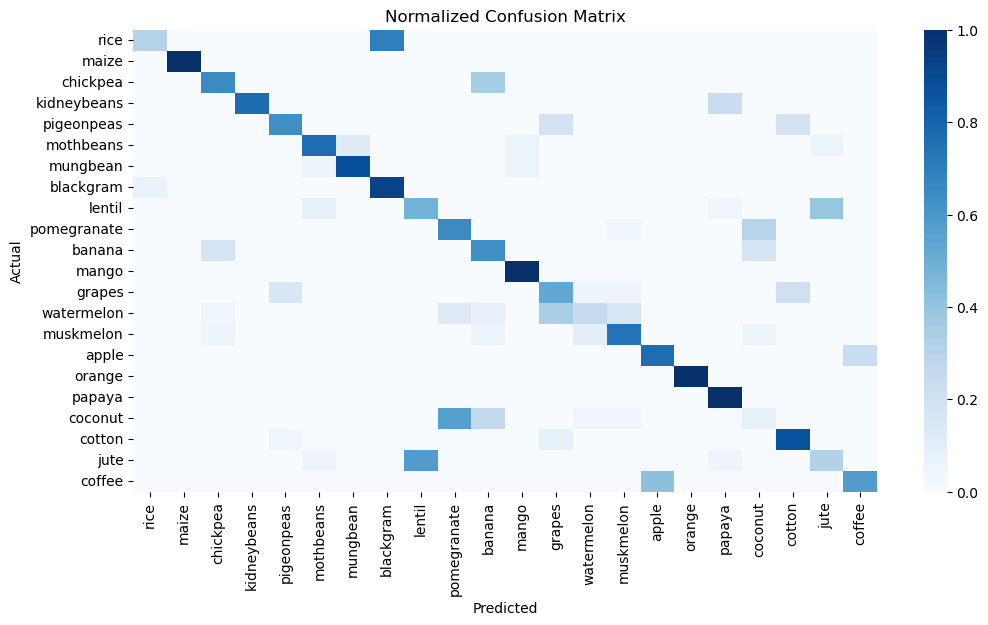

In [151]:
cm_normalized = cm_df.div(cm_df.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
sns.heatmap(cm_normalized, cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix reveals that the model performs well for crops with distinct soil profiles, as shown by the strong diagonal for classes such as maize, mango, orange, and cotton. However, it struggles to differentiate between agriculturally similar crops, leading to noticeable cluster-based misclassifications. In particular, legumes (e.g., chickpea, kidney beans, pigeon peas, and mung bean) are frequently confused with one another due to similar nutrient requirements, while fruit crops like watermelon, muskmelon, grapes, and banana also exhibit overlapping predictions. Additional confusion appears between crops such as rice and blackgram, and coconut with banana or pomegranate. These patterns indicate that the model is not making random errors but is limited by the similarity of feature values across certain crop groups, suggesting that the current set of features (N, P, K, and pH) lacks sufficient discriminatory power to fully separate all 22 classes.

**4.5 Single Variable Logistic Regression Models**

In [152]:
# Initiate an empty dictionary
results = {}

for feature in features:
    
    # Use only ONE feature
    X_single = crops_df[[feature]]
    y = crops_df["crop"]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_single, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train model
    model = LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000
    )
    
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = metrics.accuracy_score(y_test, y_pred)
    
    results[feature] = acc

In [153]:
results

{'N': 0.14772727272727273,
 'P': 0.20681818181818182,
 'K': 0.30227272727272725,
 'ph': 0.09772727272727273}

| Feature | Accuracy     |
| ------- | ------------ |
| **K**   | **0.302** 🟢 |
| **P**   | 0.207 🟠     |
| **N**   | 0.147 🔵     |
| **pH**  | **0.098** 🔴 |


In [154]:
# Best predictive feature
key = max(results, key=results.get)
best_predictive_feature = {key: results[key]}
print(f"Best predictive feature is {best_predictive_feature}")

Best predictive feature is {'K': 0.30227272727272725}


**5. Conclusions**

Although pH showed strong coefficients in the full logistic regression model, single-feature experiments revealed that potassium (K) has the highest standalone predictive power. This indicates that crop classification depends more on nutrient differentiation than soil acidity alone, and that feature interactions are critical for accurate prediction.

*Single-feature models fail because:*
- Crops are multidimensional
- Need interaction between:
    - nutrients (N, P, K)
    - soil conditions (pH)

- Feature-level analysis showed that potassium (K) provides the strongest separation between crops, while pH alone is insufficient due to overlapping distributions. This demonstrates that crop classification is inherently a multivariate problem requiring interaction between soil nutrients and environmental factors.

- K provides the best class separation because it shows clear polarity across crops, while pH, despite having extreme values, suffers from heavy overlap in the central range, making it a poor standalone predictor.

- Accurate crop prediction requires using multiple soil features together rather than relying on a single variable.

**6. Recommendations**

- Add environmental variables (rainfall, temperature, etc.)
- Use multiple features together rather than individually
- Explore more advanced models (e.g., Random Forest)
- Add additional environmental variables for better performance

**7. References**

Brady, N. C., & Weil, R. R. (2017). The nature and properties of soils (15th ed.). Pearson.

Havlin, J. L., Tisdale, S. L., Nelson, W. L., & Beaton, J. D. (2014). Soil fertility and fertilizers (8th ed.). Pearson.

Marschner, P. (2012). Marschner's mineral nutrition of higher plants (3rd ed.). Academic Press.